In [ ]:
library(ape)
library(ggtree)
library(ggplot2)
library(patchwork)
# set input and output paths

indir <- "../../results/ml_iqtree/"
outdir <- file.path(indir, "tree_plots")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

In [2]:
## function to root tree using outgroup and plot
plot_iqtree_tree <- function(tree_file, outfile_prefix, plot_title) {
	cat("Reading tree:", tree_file, "\n")

	tree <- read.tree(tree_file)
	cat("Before rooting:\n")
	print(tree)

	# IQ-TREE used -o Ip, but ape still reads the tree as unrooted.
	tree_rooted <- root(tree, outgroup = "Ip", resolve.root = TRUE)

	cat("After rooting with Ip:\n")
	print(tree_rooted)

	p <- ggtree(tree_rooted, layout = "rectangular") +
		geom_tiplab(size = 4, offset = 0.01) +
		geom_text2(
			aes(subset = !isTip & !is.na(label) & label != "", label = label),
			hjust = -0.3,
			vjust = -0.3,
			size = 3.5
		) +
		ggtitle(plot_title) +
		theme_tree2()

	print(p)
	pdf_file <- paste0(outfile_prefix, ".pdf")
	png_file <- paste0(outfile_prefix, ".png")

	ggsave(pdf_file, plot = p, width = 7, height = 5)
	ggsave(png_file, plot = p, width = 7, height = 5, dpi = 300)

	cat("\n")
	return(p)
}

Reading tree: ../../results/ml_iqtree//aa_partitioned/aa_partitioned.treefile 
Before rooting:

Phylogenetic tree with 5 tips and 3 internal nodes.

Tip labels:
  Bg, Ee, Bb, Pk, Ip
Node labels:
  , 100/100, 100/100

Unrooted; includes branch length(s).
After rooting with Ip:

Phylogenetic tree with 5 tips and 4 internal nodes.

Tip labels:
  Bg, Ee, Bb, Pk, Ip
Node labels:
  Root, 100/100, 100/100, 

Rooted; includes branch length(s).



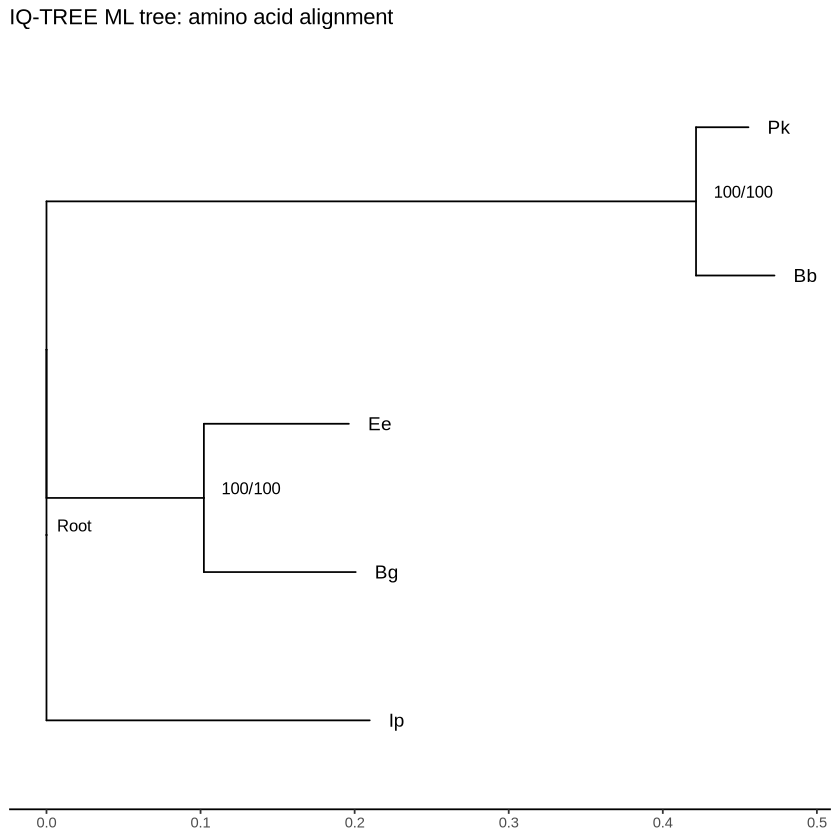

In [3]:
# plot AA tree
p_aa <- plot_iqtree_tree(
	tree_file = file.path(indir, "aa_partitioned", "aa_partitioned.treefile"),
	outfile_prefix = file.path(outdir, "aa_partitioned_iqtree_rooted"),
	plot_title = "IQ-TREE ML tree: amino acid alignment"
)

Reading tree: ../../results/ml_iqtree//nt_partitioned/nt_partitioned.treefile 
Before rooting:

Phylogenetic tree with 5 tips and 3 internal nodes.

Tip labels:
  Bg, Ee, Bb, Pk, Ip
Node labels:
  , 100/100, 100/100

Unrooted; includes branch length(s).
After rooting with Ip:

Phylogenetic tree with 5 tips and 4 internal nodes.

Tip labels:
  Bg, Ee, Bb, Pk, Ip
Node labels:
  Root, 100/100, 100/100, 

Rooted; includes branch length(s).



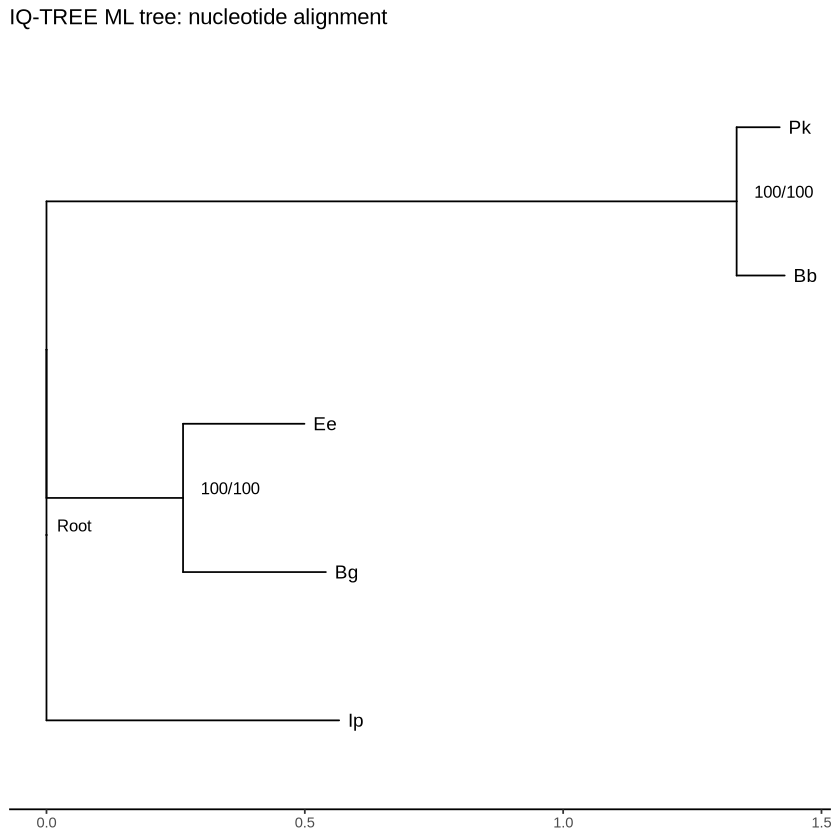

In [4]:
# plot NT tree
p_nt <- plot_iqtree_tree(
	tree_file = file.path(indir, "nt_partitioned", "nt_partitioned.treefile"),
	outfile_prefix = file.path(outdir, "nt_partitioned_iqtree_rooted"),
	plot_title = "IQ-TREE ML tree: nucleotide alignment"
)



In [12]:
# compare the two trees side by side
combined_plot <- p_aa + p_nt + plot_layout(ncol = 2)
ggsave( filename = file.path(outdir, "comparison_aa_nt_iqtree_rooted.pdf"), plot = combined_plot, width = 16, height = 5)
ggsave(filename = file.path(outdir, "comparison_aa_nt_iqtree_rooted.png"), plot = combined_plot, width = 16, height = 5, dpi = 300 )

cat("Wrote combined AA/NT comparison plot\n")

Wrote combined AA/NT comparison plot
